Found 12 B2‑ tile(s).
Computing class statistics from full‑resolution rasters ...
  Processed B2-083-2024AA_RGB
  Processed B2-084-2024AA_RGB
  Processed B2-085-2024AA_RGB
  Processed B2-086-2024AA_RGB
  Processed B2-098-2024AA_RGB
  Processed B2-099-2024AA_RGB
  Processed B2-100-2024AA_RGB
  Processed B2-101-2024AA_RGB
  Processed B2-113-2024AA_RGB
  Processed B2-114-2024AA_RGB
  Processed B2-115-2024AA_RGB
  Processed B2-116-2024AA_RGB

Class statistics (all B2‑ tiles combined):
Class                                   Pixel count Percentage
--------------------------------------------------------------
coniferousforestdrawn                 2,162,182,247     70.38%
fieldagriculturedrawn                   778,083,762     25.33%
urbanbuiltupbareterritoriesdrawn        131,733,991      4.29%
--------------------------------------------------------------
Total valid pixels                    3,072,000,000

CSV saved to D:\data\master_thesis\exports\object_classification_results\B_files_co

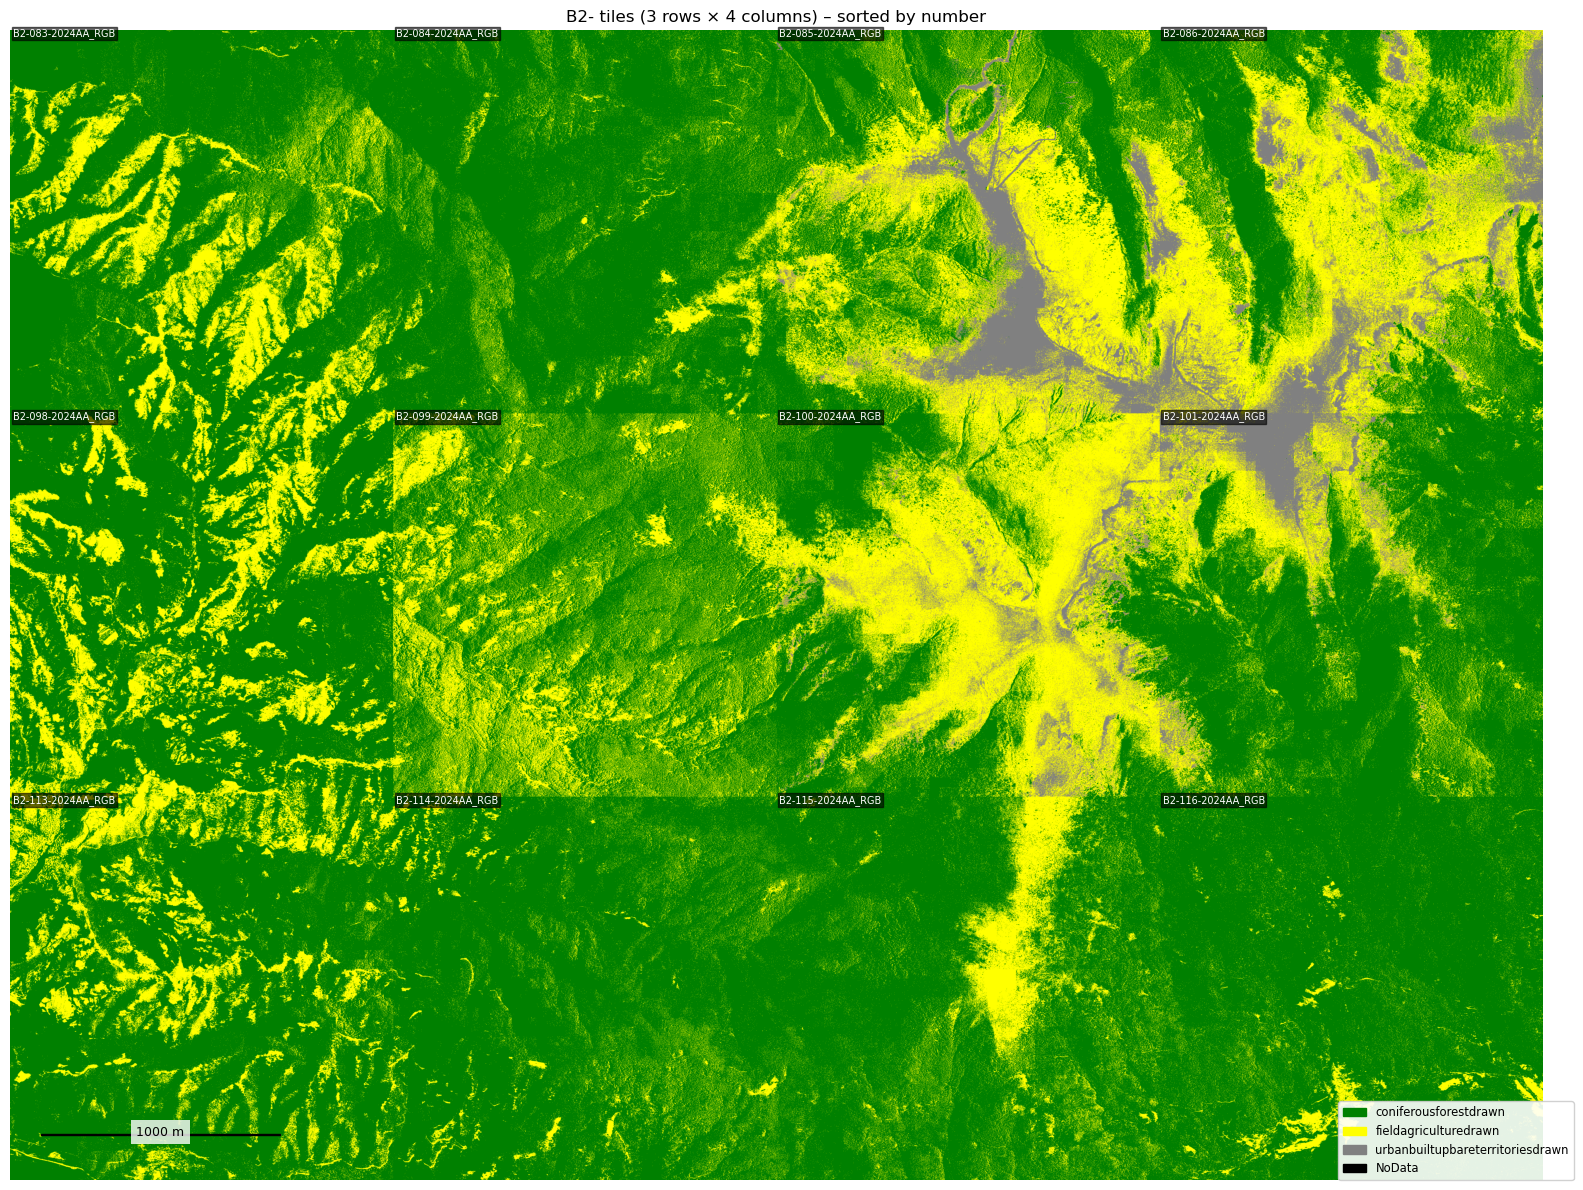

PNG saved to D:\data\master_thesis\exports\object_classification_results\B_files_combined\B2_merged_mosaic.png
GeoTIFF saved to D:\data\master_thesis\exports\object_classification_results\B_files_combined\B2_merged_mosaic.tif


In [4]:
import os
import re
import pickle
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from rasterio.crs import CRS
from PIL import Image

# ── Paths ───────────────────────────────────────────────────────────────
# Base directory containing B2‑* tile folders (each with OTB classification results)
# Основна директория, съдържаща папките с плочки B2‑* (класификационни резултати от OTB)
base_dir = r"D:\data\master_thesis\exports\object_classification_results"

# Reference GeoTIFF file used to extract the coordinate reference system (CRS).
# Референтен GeoTIFF файл, от който се извлича координатната референтна система (CRS).
ref_tif  = r"D:\data\master_thesis\exports\sentinel2_fire_images\classification_report\best_classifier\fire_04_random_forest_classification.tif"

# Output directory for merged mosaic and statistics
# Изходна директория за комбинираната мозайка и статистики
out_dir  = os.path.join(base_dir, "B_files_combined")
os.makedirs(out_dir, exist_ok=True)

# ── Settings ────────────────────────────────────────────────────────────
# Downscaling factor for the visual mosaic (smaller = sharper, larger = coarser)
# Коефициент на намаляване на разделителната способност за мозайката (по-малък = по-детайлно)
downscale = 10               # factor for visual mosaic (lower = sharper)

# Number of columns in the mosaic grid
# Брой колони в решетката на мозайката
grid_cols = 4                # columns in the mosaic grid

# ── Colour map (normalised names → 8‑bit RGB) ───────────────────────────
# Defines the colours used for each land cover class in the final visualisation.
# Задава цветовете за всеки клас земно покритие в крайната визуализация.
colour_map = {
    'coniferousforestdrawn':            (  0, 128,   0),   # dark green / тъмнозелено
    'fieldagriculturedrawn':            (255, 255,   0),   # yellow / жълто
    'urbanbuiltupbareterritoriesdrawn': (128, 128, 128),   # gray / сиво
}
fallback_colour = (200, 200, 200)    # light grey / светло сиво за непознати класове

# ── Helpers ─────────────────────────────────────────────────────────────
def normalise(name):
    """
    Remove optional 'fire4' prefix from class names to allow merging of
    slightly different naming conventions (e.g. 'fire4coniferous...' -> 'coniferous...').
    Премахва евентуален префикс 'fire4' от имената на класовете, за да се
    обединят леко различни конвенции (напр. 'fire4coniferous...' -> 'coniferous...').
    """
    if name.lower().startswith('fire4'):
        return name[5:]
    return name

def class_to_rgb(class_img, nodata, norm_dict):
    """
    Convert a single‑band classification image (integer IDs) into a 3‑band RGB image
    using the provided colour map and NoData handling.
    Конвертира едноканално класификационно изображение (целочислени ID) в
    триканално RGB изображение с помощта на зададената цветова карта и обработка на NoData.
    """
    max_id = max(norm_dict.keys())
    palette = np.zeros((max_id + 1, 3), dtype=np.uint8)
    for cid, nname in norm_dict.items():
        palette[cid] = colour_map.get(nname, fallback_colour)
    img = class_img.copy()
    if nodata is not None:
        nd_idx = max_id + 1
        img[img == nodata] = nd_idx
        palette = np.vstack([palette, [[0, 0, 0]]])   # black nodata / черен за NoData
    return palette[img]

# ── 1. Discover B2‑* tiles, sort by number ──────────────────────────────
# Scan the base directory for folders starting with "B2-" and collect the
# classification raster and its class‑name pickle file.
# Сканира основната директория за папки, започващи с "B2-", и събира
# класификационния растер и файла с имената на класовете (.pkl).
tile_info = []   # (tif_path, pkl_path, folder_name)
for root, dirs, files in os.walk(base_dir):
    folder = os.path.basename(root)
    if not folder.startswith("B2-"):
        continue
    for f in files:
        if f.endswith('_obia_true.tif'):
            tif_path = os.path.join(root, f)
            pkl_path = tif_path.replace('_obia_true.tif', '_class_names.pkl')
            if not os.path.exists(pkl_path):
                pkls = [p for p in os.listdir(root) if p.endswith('.pkl')]
                if len(pkls) == 1:
                    pkl_path = os.path.join(root, pkls[0])
                else:
                    continue
            tile_info.append((tif_path, pkl_path, folder))

def extract_number(folder_name):
    """
    Extract the numeric suffix from a folder name like 'B2-123'.
    Извлича цифровия суфикс от име на папка като 'B2-123'.
    """
    match = re.search(r'B2-(\d+)', folder_name)
    return int(match.group(1)) if match else float('inf')
tile_info.sort(key=lambda x: extract_number(x[2]))

print(f"Found {len(tile_info)} B2‑ tile(s).")

# ── 2. Class statistics (full resolution) ──────────────────────────────
# Compute the total pixel count for each land cover class across all tiles.
# Изчислява общия брой пиксели за всеки клас земно покритие за всички плочки.
print("Computing class statistics from full‑resolution rasters ...")
cumulative_counts = {}       # normalised_name -> pixel count / име на клас -> брой пиксели
total_valid_px = 0

for tif_path, pkl_path, folder in tile_info:
    with open(pkl_path, 'rb') as pf:
        data = pickle.load(pf)
    if isinstance(data, dict):
        id2name = data
    elif isinstance(data, (list, tuple)):
        id2name = {i: n for i, n in enumerate(data)}
    else:
        continue
    id_to_norm = {cid: normalise(name) for cid, name in id2name.items()}
    with rasterio.open(tif_path) as src:
        img = src.read(1)           # full resolution, band 1 / пълна резолюция, канал 1
        nodata = src.nodata
    if nodata is not None:
        valid_mask = (img != nodata)
        valid_pixels = img[valid_mask]
    else:
        valid_pixels = img.flatten()
    class_ids, cnts = np.unique(valid_pixels, return_counts=True)
    for cid, cnt in zip(class_ids, cnts):
        if cid in id_to_norm:
            name = id_to_norm[cid]
            cumulative_counts[name] = cumulative_counts.get(name, 0) + cnt
    total_valid_px += len(valid_pixels)
    print(f"  Processed {folder}")

stats = []
for name, count in cumulative_counts.items():
    pct = (count / total_valid_px) * 100 if total_valid_px > 0 else 0.0
    stats.append((name, count, pct))
stats.sort(key=lambda x: x[1], reverse=True)

print("\nClass statistics (all B2‑ tiles combined):")
print(f"{'Class':<35} {'Pixel count':>15} {'Percentage':>10}")
print("-" * 62)
for name, cnt, pct in stats:
    print(f"{name:<35} {cnt:>15,} {pct:>9.2f}%")
print("-" * 62)
print(f"{'Total valid pixels':<35} {total_valid_px:>15,}")
print()

# Save statistics as CSV
# Записва статистиките в CSV файл
csv_path = os.path.join(out_dir, "class_statistics.csv")
with open(csv_path, 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Class", "Pixel Count", "Percentage"])
    for name, cnt, pct in stats:
        writer.writerow([name, cnt, f"{pct:.2f}"])
print(f"CSV saved to {csv_path}")

# ── 3. Build down‑sampled RGB tiles for the mosaic ──────────────────────
# Downscale each classification tile and convert it to an RGB image.
# Намалява мащаба на всяка класификационна плочка и я преобразува в RGB изображение.
print("\nBuilding RGB mosaic ...")
rgb_tiles = []
tile_labels = []
scale_m_per_px = None   # metres per pixel / метра на пиксел

for tif_path, pkl_path, folder in tile_info:
    with open(pkl_path, 'rb') as pf:
        data = pickle.load(pf)
    if isinstance(data, dict):
        id2name = data
    elif isinstance(data, (list, tuple)):
        id2name = {i: n for i, n in enumerate(data)}
    else:
        continue
    norm = {cid: normalise(name) for cid, name in id2name.items()}

    with rasterio.open(tif_path) as src:
        h = src.height // downscale
        w = src.width  // downscale
        img = src.read(1, out_shape=(h, w), resampling=Resampling.nearest)
        nodata = src.nodata
        if scale_m_per_px is None and src.crs is not None:
            orig_px = abs(src.transform.a)
            scale_m_per_px = orig_px * (src.width / w)
    rgb = class_to_rgb(img, nodata, norm)
    rgb_tiles.append(rgb)
    tile_labels.append(folder)

if scale_m_per_px is None:
    scale_m_per_px = 1.0   # fallback if no CRS at all / резервна стойност при липса на CRS
    print("Warning: No CRS found – scale bar will assume 1 m per pixel.")
else:
    print(f"Pixel size for scale bar and GeoTIFF: {scale_m_per_px:.2f} m")

# ── 4. Resize tiles to a common size (median) ───────────────────────────
# Ensure all tiles have the same dimensions for the mosaic grid.
# Осигурява еднакви размери на всички плочки за решетката на мозайката.
heights = [t.shape[0] for t in rgb_tiles]
widths  = [t.shape[1] for t in rgb_tiles]
target_h = int(np.median(heights))
target_w = int(np.median(widths))

resized = []
for rgb in rgb_tiles:
    pil_img = Image.fromarray(rgb)
    pil_img = pil_img.resize((target_w, target_h), Image.NEAREST)
    resized.append(np.array(pil_img))

# ── 5. Arrange into a grid (4 columns, row‑major) ──────────────────────
# Place the resized tiles on a canvas, row by row.
# Разполага преоразмерените плочки върху платно, ред по ред.
n_tiles = len(resized)
grid_rows = int(np.ceil(n_tiles / grid_cols))

canvas_h = target_h * grid_rows
canvas_w = target_w * grid_cols
canvas = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)

for idx, rgb in enumerate(resized):
    row = idx // grid_cols
    col = idx % grid_cols
    y1 = row * target_h
    y2 = y1 + target_h
    x1 = col * target_w
    x2 = x1 + target_w
    canvas[y1:y2, x1:x2, :] = rgb

# ── 6. Plot the mosaic with scale bar ──────────────────────────────────
# Visualise the combined mosaic, adding tile labels, a scale bar, and a legend.
# Визуализира комбинираната мозайка, като добавя етикети на плочките, линеен мащаб и легенда.
fig, ax = plt.subplots(figsize=(16, 12))
ax.imshow(canvas)
ax.set_title(f"B2‑ tiles ({grid_rows} rows × {grid_cols} columns) – sorted by number")
ax.axis('off')

for idx, label in enumerate(tile_labels):
    row = idx // grid_cols
    col = idx % grid_cols
    y = row * target_h + 24
    x = col * target_w + 12
    ax.text(x, y, label, fontsize=7, color='white',
            bbox=dict(facecolor='black', alpha=0.6, pad=1))

# Scale bar / линеен мащаб
def nice_round_distance(m_per_px, max_px=0.2 * canvas_w):
    """
    Choose a “nice” round distance (in metres) for the scale bar that is
    reasonably large but fits within max_px pixels.
    Избира "хубаво" кръгло разстояние (в метри) за линейния мащаб, което е
    достатъчно голямо, но се побира в зададения брой пиксели.
    """
    target_px = max_px * 0.8
    best_m = 10 ** round(np.log10(target_px * m_per_px))
    while best_m / m_per_px > target_px:
        best_m /= 2
    while best_m / m_per_px < target_px * 0.3:
        best_m *= 2
    return int(best_m)

scale_m = nice_round_distance(scale_m_per_px)
scale_px = scale_m / scale_m_per_px

bar_x = 0.02 * canvas_w
bar_y = 0.96 * canvas_h
bar_h = 4
rect = plt.Rectangle((bar_x, bar_y), scale_px, bar_h,
                     linewidth=1, edgecolor='black', facecolor='white')
ax.add_patch(rect)
ax.text(bar_x + scale_px / 2, bar_y + bar_h + 15,
        f"{scale_m} m", ha='center', va='bottom', fontsize=9,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Legend / легенда
all_names = set()
for _, pkl_path, _ in tile_info:
    with open(pkl_path, 'rb') as pf:
        data = pickle.load(pf)
    if isinstance(data, dict):
        names = data.values()
    elif isinstance(data, (list, tuple)):
        names = data
    else:
        continue
    for name in names:
        all_names.add(normalise(name))

patches = []
for nm in sorted(all_names):
    col = colour_map.get(nm, fallback_colour)
    patches.append(mpatches.Patch(color=np.array(col)/255.0, label=nm))
patches.append(mpatches.Patch(color='black', label='NoData'))
ax.legend(handles=patches, loc='lower right', framealpha=0.9, fontsize='small',
          bbox_to_anchor=(1.02, 0), borderaxespad=0.)
plt.tight_layout()
plt.show()

# ── 7. Export mosaic as PNG and GeoTIFF ────────────────────────────────
# Save the canvas both as a simple PNG image and as a georeferenced GeoTIFF.
# Записва платното както като просто PNG изображение, така и като георефериран GeoTIFF.

# PNG / PNG изображение
png_path = os.path.join(out_dir, "B2_merged_mosaic.png")
Image.fromarray(canvas).save(png_path)
print(f"PNG saved to {png_path}")

# GeoTIFF with CRS and a non‑identity transform
# GeoTIFF с CRS и неизродена трансформация
with rasterio.open(ref_tif) as ref:
    target_crs = ref.crs
if target_crs is None:
    target_crs = CRS.from_epsg(32632)   # UTM zone 32N as fallback / резервна проекция
    print("Reference CRS is None, using EPSG:32632")

# Use a transform where the top-left corner is at (0, canvas_h * scale_m_per_px)
# This avoids the identity transform warning while keeping the pixel size correct.
# Използва трансформация, при която горният ляв ъгъл е в (0, canvas_h * scale_m_per_px),
# което позволява да се избегне предупреждението за identity transform и запазва размера на пиксела.
transform = from_origin(0, canvas_h * scale_m_per_px, scale_m_per_px, scale_m_per_px)

tif_path = os.path.join(out_dir, "B2_merged_mosaic.tif")
with rasterio.open(
    tif_path, 'w',
    driver='GTiff',
    height=canvas_h,
    width=canvas_w,
    count=3,
    dtype=canvas.dtype,
    crs=target_crs,
    transform=transform,
) as dst:
    dst.write(canvas[:, :, 0], 1)
    dst.write(canvas[:, :, 1], 2)
    dst.write(canvas[:, :, 2], 3)
print(f"GeoTIFF saved to {tif_path}")